                                                                       Water potability( صلاحية المياه للشرب)                                                                            

المكتبات

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#ادوات preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#المودلز
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#التقييم
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

print('done')

d:\Applications\Anaconda3\c\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


done


بنقرأ الداتا

In [3]:
#قراءة الداتا 
df = pd.read_csv(r"C:\Users\moham\Downloads\Ai for Business project\4_5999069023218703185.csv")

#نشوف شكل الداتا
print(df.shape)
df.head()

(3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


missing valuesبنتأكد من موضوع ال

In [4]:
# نطبع معلومات عن الداتا عشان نشوف missing values
print(df.info())

#نشوف عدد القيم المفقودة في كل عمود
print(df.isnull().sum())

#نشوف توزيع الـ target
print(df['Potability'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Potability
0    1998
1    1278
Name: count, dtype: i

بنقسم الداتا

In [5]:
# نفصل الـ features عن الـ target
X = df.drop('Potability', axis=1)
y = df['Potability']

# نقسم البيانات train 80% و test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2620, 9)
(656, 9)


نتعامل مع ال missing values

In [6]:
# بنستخدم median عشان نعوض القيم المفقودة
imputer = SimpleImputer(strategy='median')

# بنطبق على training data
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# بنحولهم تاني لـ dataframe عشان نسهل التعامل
X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns)
X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns)

# نتأكد ان مفيش missing values
print(X_train_imp.isnull().sum().sum())

0


نوزع الـ Target

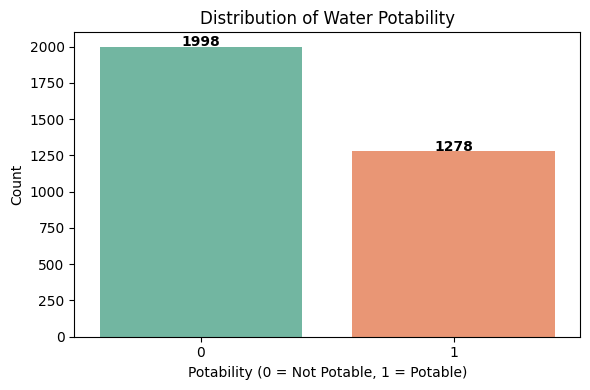

Percentage of each class:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


In [7]:
# بنوزع الـ Target
plt.figure(figsize=(6, 4))

sns.countplot(x='Potability', data=df, palette='Set2')

plt.title('Distribution of Water Potability')
plt.xlabel('Potability (0 = Not Potable, 1 = Potable)')
plt.ylabel('Count')

for i in range(2):
    count = df['Potability'].value_counts()[i]
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Percentage of each class:')
print(df['Potability'].value_counts(normalize=True) * 100)

Histogram 

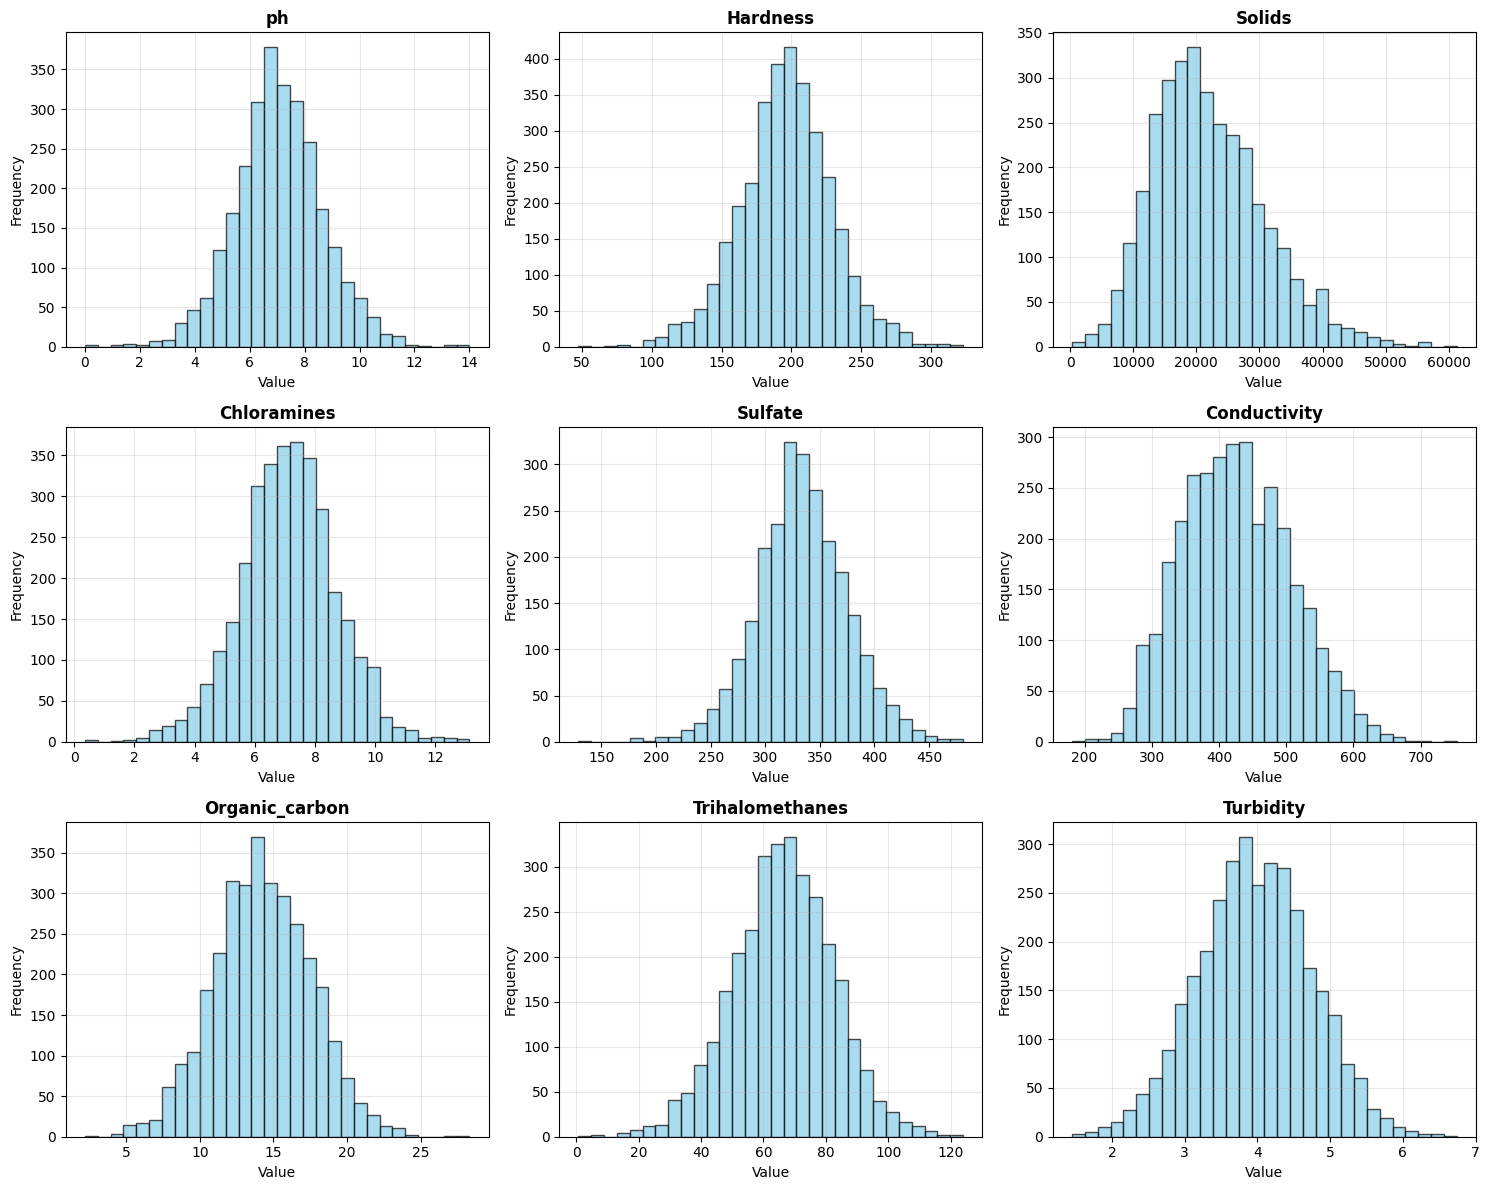

In [8]:
# نوزع كل المتغيرات
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    axes[i].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

for i in range(len(df.columns)-1, 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Boxplot (preprocessing قبل)

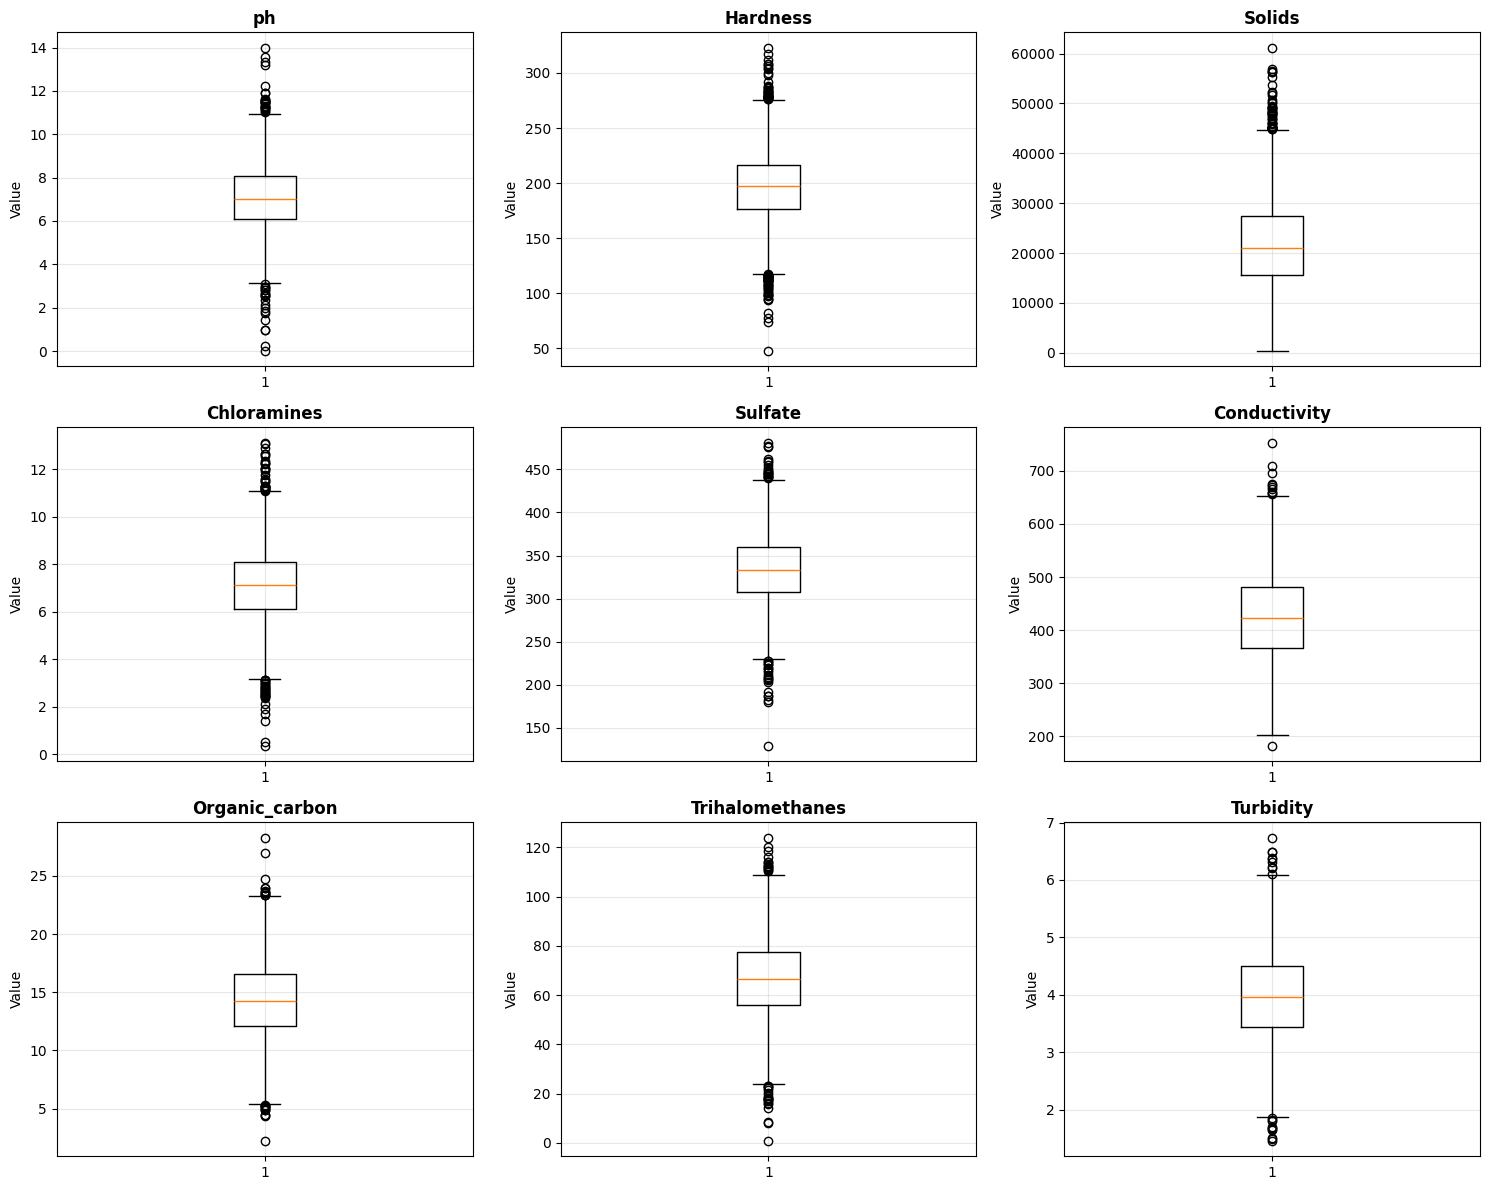

In [9]:
# Boxplot قبل preprocessing
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

for i in range(len(df.columns)-1, 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Correlation Matrix (preprocessing قبل)

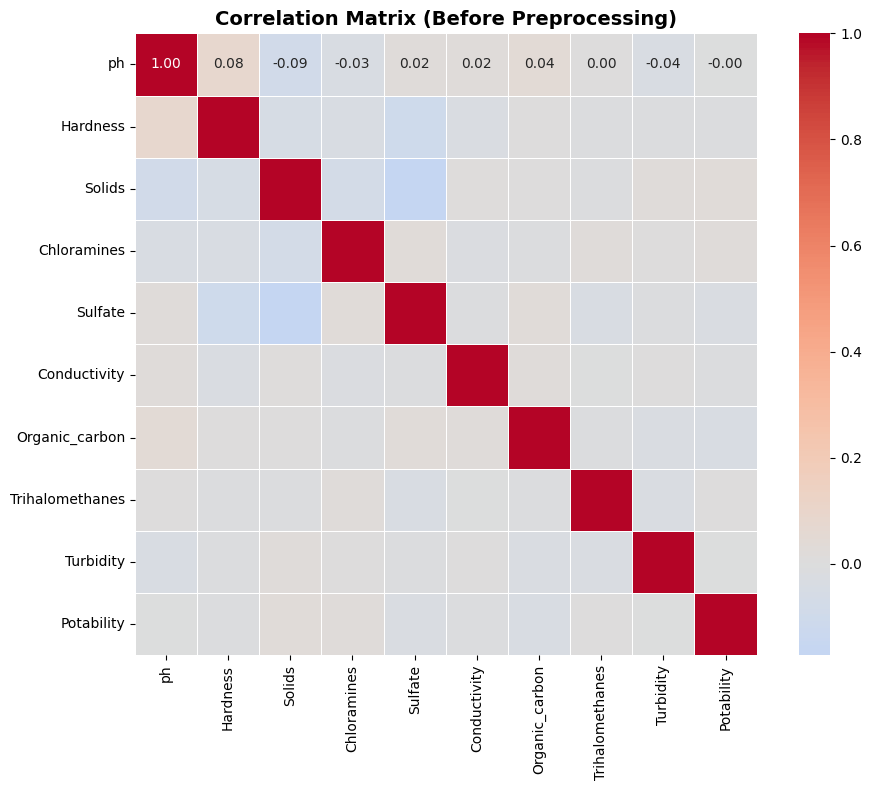

Strongest correlations with Potability:
Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64


In [10]:
# Correlation Matrix قبل preprocessing
plt.figure(figsize=(10, 8))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)

plt.title('Correlation Matrix (Before Preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Strongest correlations with Potability:')
print(corr_matrix['Potability'].sort_values(ascending=False))

نعالج الـ Outliers

In [11]:
# بنعمل نسخة من الداتا عشان نعدل عليها
X_train_clean = X_train_imp.copy()
X_test_clean = X_test_imp.copy()

# بنمر على كل عمود ونشيل القيم الشاذة باستخدام IQR
for col in X_train_clean.columns:
    Q1 = X_train_clean[col].quantile(0.25)
    Q3 = X_train_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # بنحط القيم اللي برا الحدود عند الحدود نفسها
    X_train_clean[col] = np.where(X_train_clean[col] < lower, lower, X_train_clean[col])
    X_train_clean[col] = np.where(X_train_clean[col] > upper, upper, X_train_clean[col])
    
    X_test_clean[col] = np.where(X_test_clean[col] < lower, lower, X_test_clean[col])
    X_test_clean[col] = np.where(X_test_clean[col] > upper, upper, X_test_clean[col])

print('outliers done')

outliers done


Standardization

In [12]:
# بنستخدم StandardScaler عشان نوحد المقاييس
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print('scaling done')

scaling done


Boxplot (preprocessing بعد)

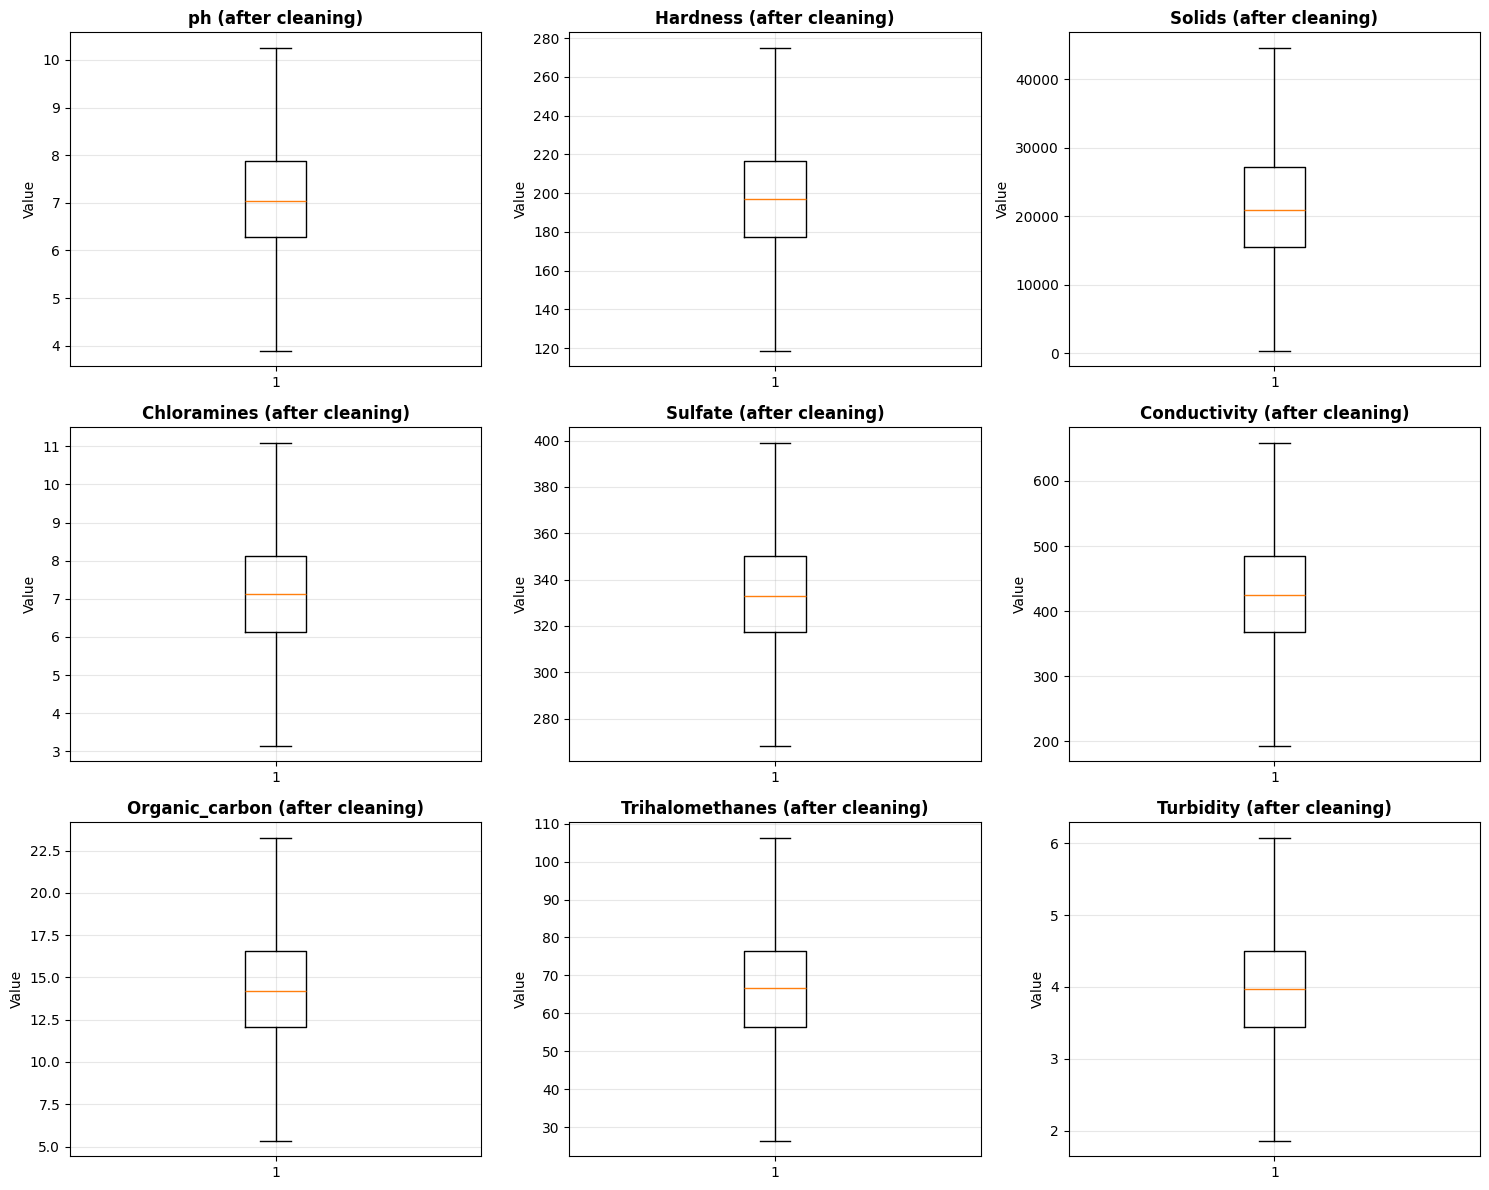

In [13]:
# Boxplot بعد preprocessing
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(X_train_clean.columns):
    axes[i].boxplot(X_train_clean[col])
    axes[i].set_title(col + ' (after cleaning)', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

for i in range(len(X_train_clean.columns), 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

مقارنة Boxplot

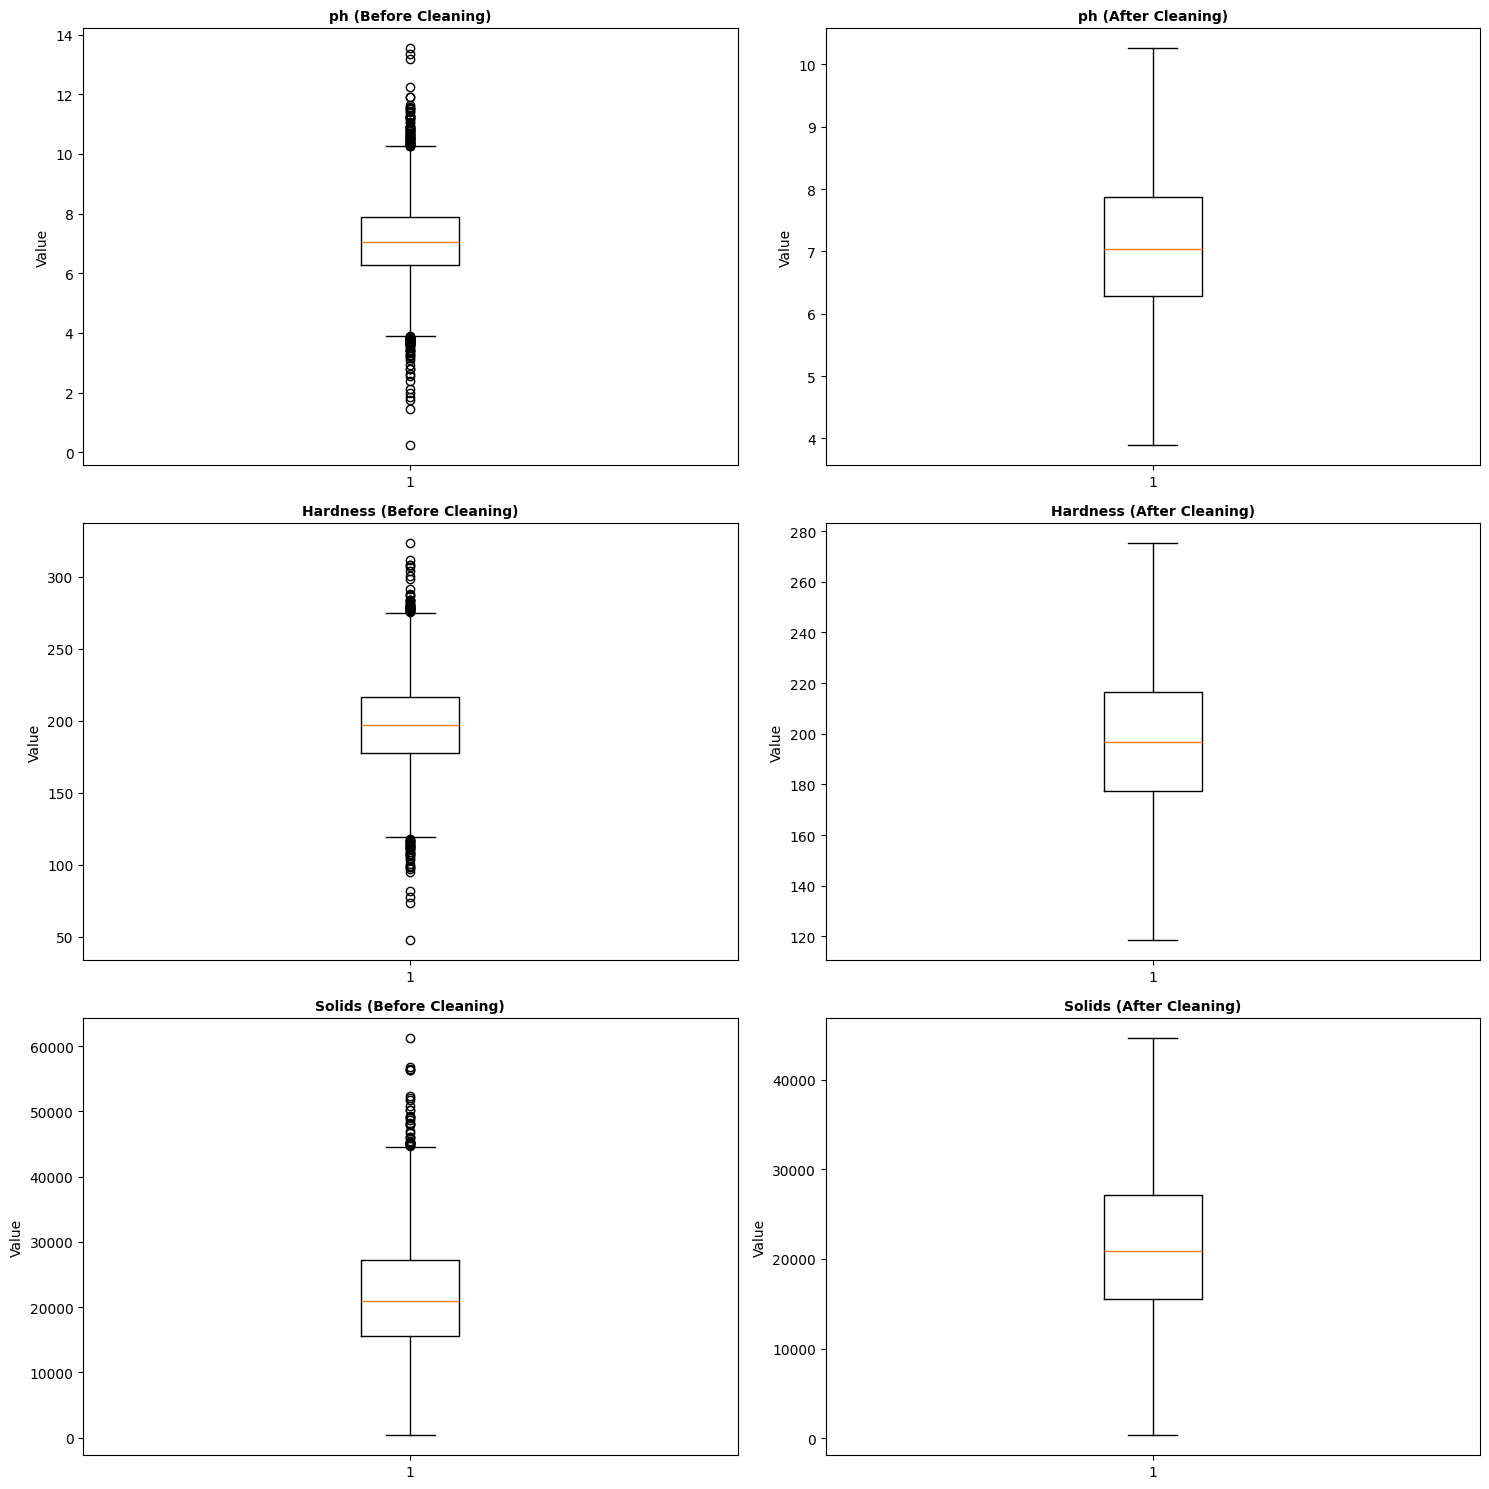

In [14]:
# مقارنة قبل وبعد الـ cleaning
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

# نختار 3 أعمدة عشان 3*2 = 6
cols_to_plot = X_train_clean.columns[:3]

for i in range(len(cols_to_plot)):
    col = cols_to_plot[i]
    
    # قبل المعالجة
    axes[i*2].boxplot(X_train_imp[col])
    axes[i*2].set_title(col + ' (Before Cleaning)', fontsize=10, fontweight='bold')
    axes[i*2].set_ylabel('Value')
    
    # بعد المعالجة
    axes[i*2+1].boxplot(X_train_clean[col])
    axes[i*2+1].set_title(col + ' (After Cleaning)', fontsize=10, fontweight='bold')
    axes[i*2+1].set_ylabel('Value')

# نشيل الـ empty plots (لو في حاجه فاضية)
for i in range(len(cols_to_plot)*2, 6):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Correlation Matrix (preprocessing بعد)

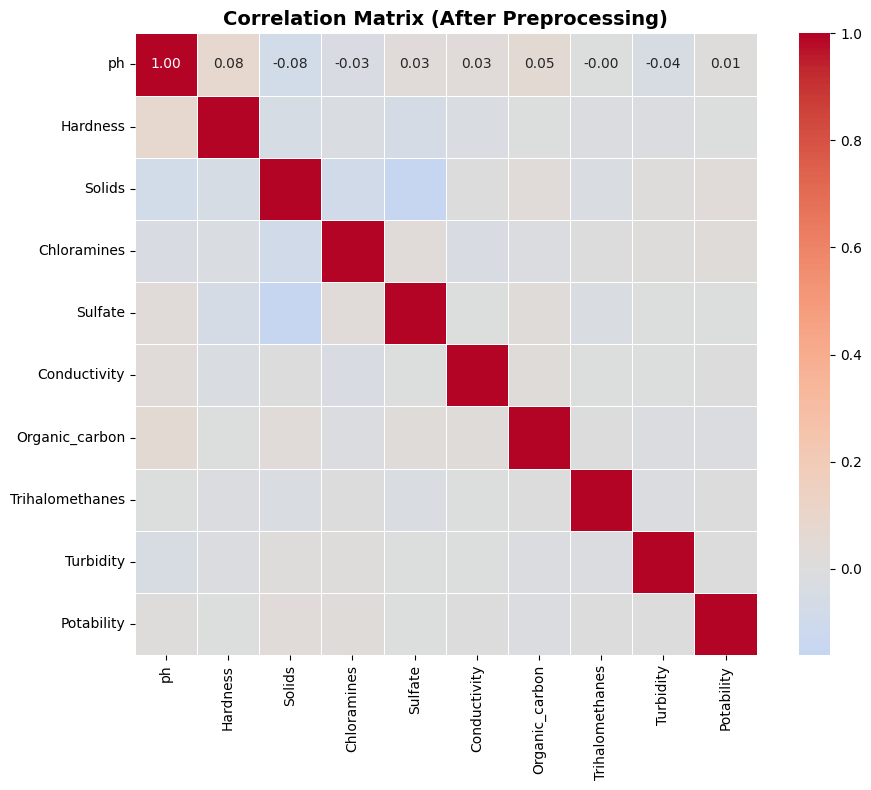

Strongest correlations after preprocessing:
Potability         1.000000
Solids             0.025325
Chloramines        0.016208
ph                 0.011948
Trihalomethanes    0.004197
Conductivity       0.003029
Turbidity          0.002229
Hardness          -0.001604
Sulfate           -0.006034
Organic_carbon    -0.012555
Name: Potability, dtype: float64


In [15]:
# Correlation Matrix بعد preprocessing
plt.figure(figsize=(10, 8))

df_clean = pd.DataFrame(X_train_scaled, columns=X_train_clean.columns)
df_clean['Potability'] = y_train.values

corr_matrix_clean = df_clean.corr()

sns.heatmap(corr_matrix_clean, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)

plt.title('Correlation Matrix (After Preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Strongest correlations after preprocessing:')
print(corr_matrix_clean['Potability'].sort_values(ascending=False))

Logistic Regression Algorithm

In [16]:
print('starting Logistic Regression...')

param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced', None]
}

# بنضبط الـ hyperparameters باستخدام GridSearch

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

print('Logistic Regression done!')
print('best params:', grid_lr.best_params_)
print('best score:', grid_lr.best_score_)

starting Logistic Regression...
Logistic Regression done!
best params: {'C': 0.1, 'class_weight': None, 'solver': 'liblinear'}
best score: 0.6103050843903425


Decision Tree Algorithm

In [17]:
print('starting Decision Tree...')

param_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train_scaled, y_train)
best_dt = grid_dt.best_estimator_

print('Decision Tree done!')
print('best params:', grid_dt.best_params_)
print('best score:', grid_dt.best_score_)

starting Decision Tree...
Decision Tree done!
best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
best score: 0.6396916390782724


Random Forest Algorithm

In [18]:
print('starting Random Forest...')

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

print('Random Forest done!')
print('best params:', grid_rf.best_params_)
print('best score:', grid_rf.best_score_)

starting Random Forest...
Random Forest done!
best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
best score: 0.6767133856355115


XGBoost Algorithm

In [19]:
print('starting XGBoost...')

param_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'scale_pos_weight': [1, 1.5]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss'),
    param_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train)
best_xgb = grid_xgb.best_estimator_

print('XGBoost done!')
print('best params:', grid_xgb.best_params_)
print('best score:', grid_xgb.best_score_)

starting XGBoost...
XGBoost done!
best params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.9}
best score: 0.6675574463326002


SVM Algorithm

In [20]:
print('starting SVM...')

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced', None]
}

grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)
best_svm = grid_svm.best_estimator_

print('SVM done!')
print('best params:', grid_svm.best_params_)
print('best score:', grid_svm.best_score_)

starting SVM...
SVM done!
best params: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
best score: 0.6713752607026805


KNN Algorithm

In [21]:
print('starting KNN...')

param_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_

print('KNN done!')
print('best params:', grid_knn.best_params_)
print('best score:', grid_knn.best_score_)

starting KNN...
KNN done!
best params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
best score: 0.6438956472809595


بنجمع النتايج لكل المودلز

In [22]:
# هنحط كل المودلز في dictionary عشان نسهل المقارنة
models = {
    'Logistic Regression': best_lr,
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'SVM': best_svm,
    'KNN': best_knn
}

# بنخزن النتايج في list
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })

# نحول النتايج لـ dataframe ونرتبها
final_results = pd.DataFrame(results)
final_results = final_results.sort_values('Accuracy', ascending=False)

print(final_results)

                 Model  Accuracy  F1-Score  Precision    Recall
3              XGBoost  0.664634  0.460784   0.618421  0.367188
2        Random Forest  0.660061  0.405333   0.638655  0.296875
1        Decision Tree  0.647866  0.356546   0.621359  0.250000
4                  SVM  0.623476  0.418824   0.526627  0.347656
5                  KNN  0.620427  0.385185   0.523490  0.304688
0  Logistic Regression  0.609756  0.000000   0.000000  0.000000


نقارن بقا مابين المودلز

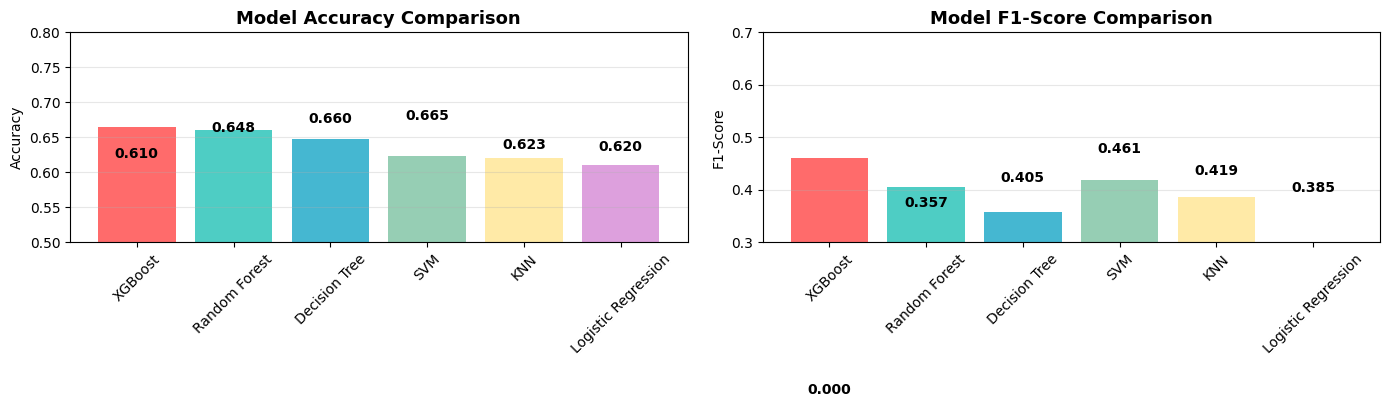

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sorted_results = final_results.sort_values('Accuracy', ascending=False)

axes[0].bar(sorted_results['Model'], sorted_results['Accuracy'], 
            color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 0.8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', alpha=0.3)

for i, row in sorted_results.iterrows():
    axes[0].text(i, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", 
                 ha='center', fontweight='bold')

axes[1].bar(sorted_results['Model'], sorted_results['F1-Score'],
            color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
axes[1].set_title('Model F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0.3, 0.7)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)

for i, row in sorted_results.iterrows():
    axes[1].text(i, row['F1-Score'] + 0.01, f"{row['F1-Score']:.3f}", 
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

بنحلل ونشوف ايه احسن مودل

Best Model: XGBoost
Accuracy: 0.6646
F1-Score: 0.4608
Precision: 0.6184
Recall: 0.3672

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.85      0.76       400
           1       0.62      0.37      0.46       256

    accuracy                           0.66       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.66      0.64       656



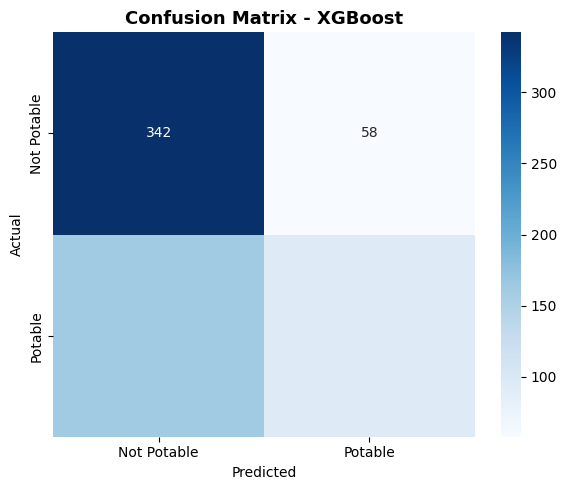

In [24]:
best_model_name = final_results.iloc[0]['Model']
best_model = models[best_model_name]

print('='*50)
print(f'Best Model: {best_model_name}')
print('='*50)

y_pred_best = best_model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_best):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_best):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Potable', 'Potable'],
            yticklabels=['Not Potable', 'Potable'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

بنعمل classification report لكل مودل عشان نشوف التفاصيل

In [25]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print('='*50)
    print(name)
    print('='*50)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656

Decision Tree
              precision    recall  f1-score   support

           0       0.65      0.90      0.76       400
           1       0.62      0.25      0.36       256

    accuracy                           0.65       656
   macro avg       0.64      0.58      0.56       656
weighted avg       0.64      0.65      0.60       656

Random Forest
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.64      0.30      0.41       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.65   

Confusion Matrices لكل مودل

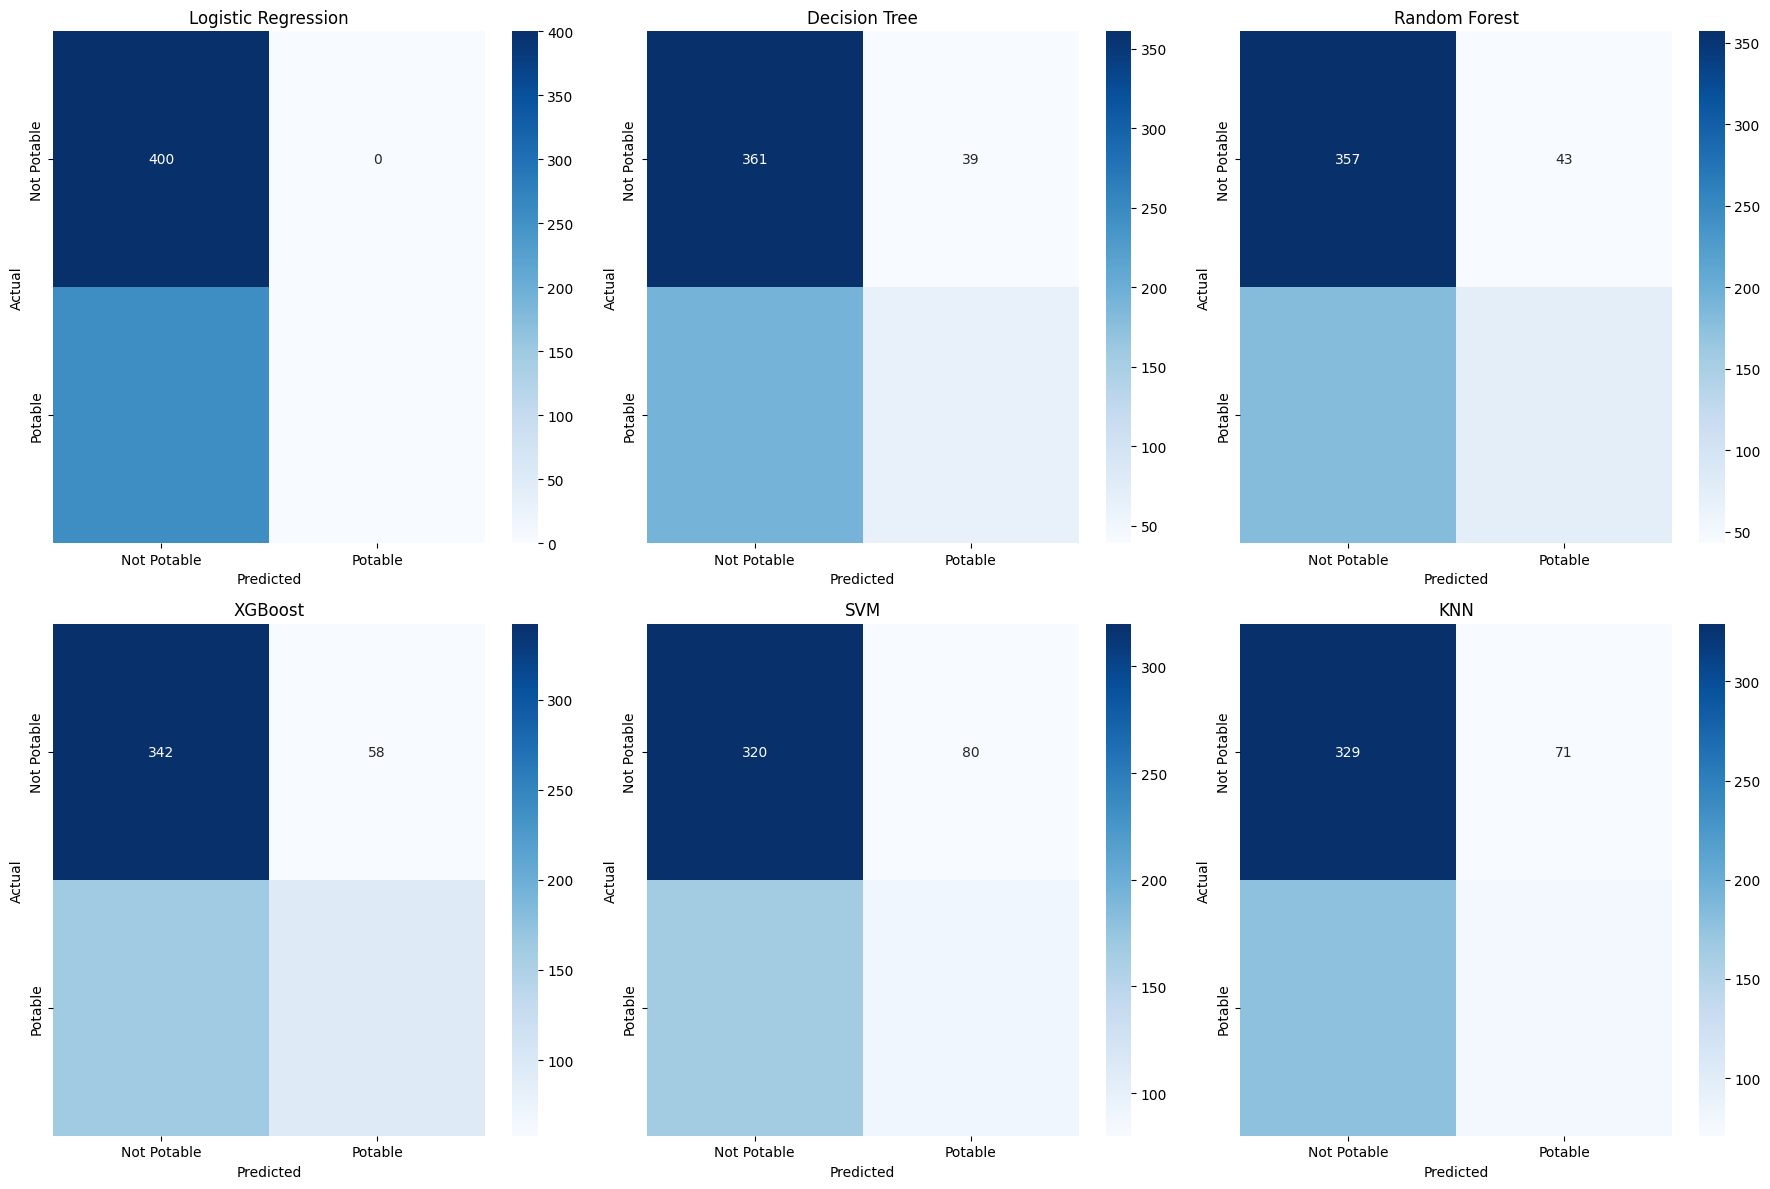

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Potable', 'Potable'],
                yticklabels=['Not Potable', 'Potable'])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

بنحفظ كل حاجه

In [27]:
# هنحفظ النتايج في فايل CSV
final_results.to_csv('final_model_comparison.csv', index=False)

# هنعمل ريبورت txt بسيط
with open('model_report.txt', 'w') as f:
    f.write('Model Comparison Results\n')
    f.write('='*50 + '\n\n')
    
    for idx, row in final_results.iterrows():
        f.write(f"Model: {row['Model']}\n")
        f.write(f"Accuracy: {row['Accuracy']:.4f}\n")
        f.write(f"F1-Score: {row['F1-Score']:.4f}\n")
        f.write(f"Precision: {row['Precision']:.4f}\n")
        f.write(f"Recall: {row['Recall']:.4f}\n")
        f.write('-'*30 + '\n')
    
    f.write(f"\nBest Model: {final_results.iloc[0]['Model']}\n")
    f.write(f"Best Accuracy: {final_results.iloc[0]['Accuracy']:.4f}")

# حفظ المودل لاستخدامه في Gradio
import joblib

# نحفظ أفضل مودل (XGBoost)
joblib.dump(best_xgb, 'water_potability_model.pkl')

# نحفظ الـ scaler عشان نستخدمه في التوحيد
joblib.dump(scaler, 'scaler.pkl')

print('✅ Model and scaler saved successfully!')
print(f'✅ Best model: {final_results.iloc[0]["Model"]}')

print('done, files saved')

✅ Model and scaler saved successfully!
✅ Best model: XGBoost
done, files saved


بنعرض بقا اللي حفظناه

In [28]:
# نشوف محتوى الملفات اللي اتحفظت
print('final results:')
print(final_results)

print('\n\nmodel report:')
with open('model_report.txt', 'r') as f:
    print(f.read())

final results:
                 Model  Accuracy  F1-Score  Precision    Recall
3              XGBoost  0.664634  0.460784   0.618421  0.367188
2        Random Forest  0.660061  0.405333   0.638655  0.296875
1        Decision Tree  0.647866  0.356546   0.621359  0.250000
4                  SVM  0.623476  0.418824   0.526627  0.347656
5                  KNN  0.620427  0.385185   0.523490  0.304688
0  Logistic Regression  0.609756  0.000000   0.000000  0.000000


model report:
Model Comparison Results

Model: XGBoost
Accuracy: 0.6646
F1-Score: 0.4608
Precision: 0.6184
Recall: 0.3672
------------------------------
Model: Random Forest
Accuracy: 0.6601
F1-Score: 0.4053
Precision: 0.6387
Recall: 0.2969
------------------------------
Model: Decision Tree
Accuracy: 0.6479
F1-Score: 0.3565
Precision: 0.6214
Recall: 0.2500
------------------------------
Model: SVM
Accuracy: 0.6235
F1-Score: 0.4188
Precision: 0.5266
Recall: 0.3477
------------------------------
Model: KNN
Accuracy: 0.6204
F1-Scor

In [29]:
#  تطبيق Water Potability باستخدام Gradio

import gradio as gr
import numpy as np
import joblib
import pandas as pd

print('🔄 Loading model...')

# تحميل المودل والـ scaler
model = joblib.load('water_potability_model.pkl')
scaler = joblib.load('scaler.pkl')

print('✅ Model loaded successfully!')

# دالة التنبؤ
def predict_water_potability(ph, Hardness, Solids, Chloramines, Sulfate,
                             Conductivity, Organic_carbon, Trihalomethanes, Turbidity):
    
    # تجهيز البيانات كـ array
    input_data = np.array([[ph, Hardness, Solids, Chloramines, Sulfate,
                           Conductivity, Organic_carbon, Trihalomethanes, Turbidity]])
    
    # توحيد البيانات (نفس الـ scaling اللي استخدمناه في التدريب)
    input_scaled = scaler.transform(input_data)
    
    # التنبؤ
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]
    
    # تجهيز النتيجة
    if prediction == 1:
        result = f'✅ صالحة للشرب'
        confidence = f'نسبة الثقة: {probability[1]*100:.2f}%'
        status = 'safe'
    else:
        result = f'❌ غير صالحة للشرب'
        confidence = f'نسبة الثقة: {probability[0]*100:.2f}%'
        status = 'unsafe'
    
    # عرض الاحتمالات
    prob_text = f"""
    📊 الاحتمالات:
    • غير صالحة: {probability[0]*100:.2f}%
    • صالحة: {probability[1]*100:.2f}%
    """
    
    return result, confidence, prob_text


# تعريف المدخلات (باستخدام Sliders)
inputs = [
    gr.Slider(0, 14, value=7.0, step=0.1, label='pH'),
    gr.Slider(0, 500, value=196.0, step=1.0, label='Hardness'),
    gr.Slider(0, 100000, value=22000.0, step=100.0, label='Solids (mg/L)'),
    gr.Slider(0, 20, value=7.1, step=0.1, label='Chloramines (mg/L)'),
    gr.Slider(0, 1000, value=333.0, step=1.0, label='Sulfate (mg/L)'),
    gr.Slider(0, 1000, value=426.0, step=1.0, label='Conductivity (μS/cm)'),
    gr.Slider(0, 50, value=14.3, step=0.1, label='Organic Carbon (mg/L)'),
    gr.Slider(0, 200, value=66.4, step=1.0, label='Trihalomethanes (μg/L)'),
    gr.Slider(0, 20, value=4.0, step=0.1, label='Turbidity (NTU)')
]

# تعريف المخرجات
outputs = [
    gr.Textbox(label='النتيجة', lines=1),
    gr.Textbox(label='نسبة الثقة', lines=1),
    gr.Textbox(label='الاحتمالات', lines=3)
]

# إنشاء التطبيق

app = gr.Interface(
    fn=predict_water_potability,
    inputs=inputs,
    outputs=outputs,
    title='💧 Water Potability Predictor',
    description='أدخل قياسات المياه لمعرفة إذا كانت صالحة للشرب',
    theme='soft',
    examples=[
        [7.0, 200, 22000, 7.0, 333, 426, 14, 66, 4.0],
        [8.0, 250, 30000, 5.0, 300, 500, 12, 70, 3.5],
        [6.0, 150, 15000, 8.0, 350, 350, 16, 60, 5.0],
    ],
    article="🔬 تم التدريب باستخدام XGBoost على بيانات Water Potability"
)

# تشغيل التطبيق
if __name__ == '__main__':
    app.launch(share=True)  # share=True عشان يطلع رابط عام

🔄 Loading model...
✅ Model loaded successfully!
* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Missing file: C:\Users\moham\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\moham\.cache\huggingface\gradio\frpc


Created dataset file at: .gradio\flagged\dataset1.csv
